Steel demand

In [2]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy.optimize import curve_fit
import pandas_datareader.wb as wb
import statsmodels.api as sm
from scipy import stats

Load data

In [3]:
# Load data

def load_files(filename):
    base_path = Path.cwd().parent
    historic_folder = base_path / "data" / "raw" / "Steel"
    
    file_path = historic_folder / filename
    df = pd.read_excel(file_path)
    
    return df

steel_file = "steel_demand.xlsx"

steel_data = load_files(steel_file)

Look at data

In [4]:
base_path = Path.cwd().parent
historic_gdp_data = pd.read_csv(base_path / "data" / "raw" / "gdp" / "gdp_1960_2024.csv")
future_gdp_data = pd.read_csv(base_path / "data" / "raw" / "gdp" / "future_gdp_2015_usd.csv")

# Create dataframe for the years 1960 to 2024 with the columns "year" and "gdp"
historic_gdp = pd.DataFrame({
    "year": np.arange(1960, 2025),
    "gdp": None
})

# Melt wide format to long format
historic_gdp_data_long = historic_gdp_data.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="year",
    value_name="gdp"
)

historic_gdp_data_long["year"] = historic_gdp_data_long["year"].astype(int)

# Then fill in the historic dataframe
for index, row in historic_gdp.iterrows():
    year = row["year"]
    match = historic_gdp_data_long.loc[historic_gdp_data_long["year"] == year, "gdp"]
    if not match.empty:
        historic_gdp.at[index, "gdp"] = match.values[0]

display(historic_gdp)

# Create dataframe for the years 2025 to 2050 with the columns "year", "SSP1", "SSP2", "SSP3" "SSP5"
future_gdp = pd.DataFrame({
    "year": np.arange(2025, 2051),
    "SSP1": None,
    "SSP2": None,
    "SSP3": None,
    "SSP5": None
})

# Fill the future_gdp dataframe with corresponding GDP values from future_gdp_data
# The data has scenario columns "SSP1", "SSP2", "SSP3" and "SSP5" and the value is in the corresponding every 5th year column (2025, 2030, ..., 2050)
# The unit column has the value "billion USD_2017/yr"
for index, row in future_gdp.iterrows():
    year = row["year"]
    if year % 5 != 0:
        continue
    for ssp in ["SSP1", "SSP2", "SSP3", "SSP5"]:
        gdp_value = future_gdp_data.loc[(future_gdp_data["scenario"] == ssp) & (future_gdp_data["unit"] == "billion USD_2015/yr"), str(year)].values[0]
        future_gdp.at[index, ssp] = gdp_value

for col in ['SSP1', 'SSP2', 'SSP3', 'SSP5']:
    future_gdp[col] = pd.to_numeric(future_gdp[col], errors='coerce')

display(future_gdp)

,year,gdp
0,1960,11069600000000.0
1,1961,11508300000000.0
2,1962,12121300000000.0
3,1963,12728300000000.0
4,1964,13567500000000.0
...,...,...
60,2020,82803300000000.0
61,2021,88113700000000.0
62,2022,91112300000000.0
63,2023,93798800000000.0


,year,SSP1,SSP2,SSP3,SSP5
0,2025,148762.427195,148762.659870,148762.626464,148762.652132
1,2026,NaN,NaN,NaN,NaN
2,2027,NaN,NaN,NaN,NaN
3,2028,NaN,NaN,NaN,NaN
4,2029,NaN,NaN,NaN,NaN
5,2030,173860.643613,173511.549917,173116.035180,174342.230265
6,2031,NaN,NaN,NaN,NaN
7,2032,NaN,NaN,NaN,NaN
8,2033,NaN,NaN,NaN,NaN
9,2034,NaN,NaN,NaN,NaN


Clean data

In [5]:
# New dataframe with relevant columns for steel production from 1850 to 1979
steel_1850 = steel_data[steel_data["Year"] < 1980][["Year", "Steel", "GDP"]].copy()

# New dataframe for steel production from 1980 to 2020
steel_1980 = steel_data[(steel_data["Year"] >= 1980) & (steel_data["Year"] < 2021)][["Year", "Steel", "GDP"]].copy()

# Ensure year columns are integers
steel_1980["Year"] = steel_1980["Year"].astype(int)
historic_gdp["year"] = historic_gdp["year"].astype(int)

# Merge GDP into steel_1980 by matching years
steel_1980 = steel_1980.merge(
    historic_gdp[["year", "gdp"]],
    left_on="Year",       # your steel dataframe column
    right_on="year",      # GDP dataframe column
    how="left"
)

# Merge steel_1850 and steel_1980 for a complete dataset from 1850 to 2020
#steel_historic = steel_1980[["Year", "Steel", "GDP"]].copy()
steel_historic = pd.concat([steel_1850, steel_1980], ignore_index=True)

# Look at the merged data
#display(steel_1980)

# Add data for steel production from 2021 to 2024
steel_2021_2024 = pd.DataFrame({
    "Year": [2021, 2022, 2023, 2024],
    "Steel": [1963, 1889, 1904, 1885] # in Mt, from World Steel Association
})

# Combine steel_historic and steel_2021_2024 for a complete dataset from 1850 to 2024
steel_historic = pd.concat([steel_1980, steel_2021_2024], ignore_index=True)

# Look at the complete dataset
display(steel_historic)

,Year,Steel,GDP,year,gdp
0,1980,717.0,NaN,1980.0,26469200000000.0
1,1981,NaN,NaN,1981.0,26973500000000.0
2,1982,NaN,NaN,1982.0,27073100000000.0
3,1983,NaN,NaN,1983.0,27767100000000.0
4,1984,NaN,NaN,1984.0,29071900000000.0
5,1985,719.0,NaN,1985.0,30139900000000.0
6,1986,NaN,NaN,1986.0,31131300000000.0
7,1987,NaN,NaN,1987.0,32288300000000.0
8,1988,NaN,NaN,1988.0,33749500000000.0
9,1989,NaN,NaN,1989.0,34987100000000.0


C:\Users\ovid\AppData\Local\Temp\ipykernel_37444\2944794306.py:3: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  steel_historic["GDP Interpolated"] = steel_historic["gdp"].interpolate(method="linear")


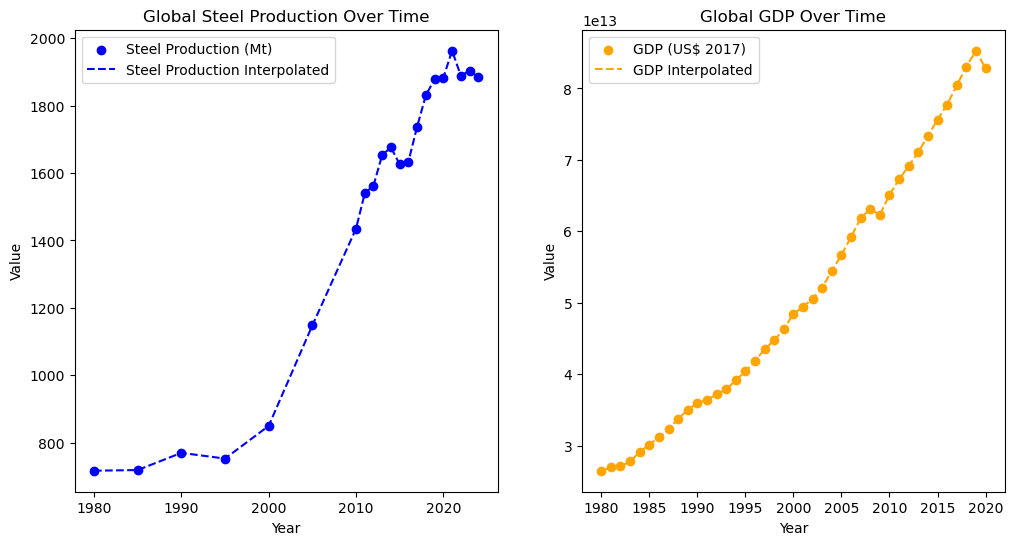

In [6]:
# Interpolate steel and GDP for missing years
steel_historic["Steel Interpolated"] = steel_historic["Steel"].interpolate(method="linear")
steel_historic["GDP Interpolated"] = steel_historic["gdp"].interpolate(method="linear")

# Plot steel production and GDP over time in two separate subplots, with interpolated values included
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(steel_historic["Year"], steel_historic["Steel"], label="Steel Production (Mt)", color="blue")
plt.plot(steel_historic["Year"], steel_historic["Steel Interpolated"], label="Steel Production Interpolated", color="blue", linestyle="--")
plt.title("Global Steel Production Over Time")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(steel_historic["Year"], steel_historic["gdp"], label="GDP (US$ 2017)", color="orange")
plt.plot(steel_historic["Year"], steel_historic["GDP Interpolated"], label="GDP Interpolated", color="orange", linestyle="--")
plt.title("Global GDP Over Time")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.show()

In [7]:
# Log transform data to check correlation of growth rates from 1995 to 2024
steel_historic_1995 = steel_historic[steel_historic["Year"] >= 1995].copy()

# Remove Nan values before log transformation
steel_historic_1995 = steel_historic_1995.dropna(subset=['Steel', 'gdp'])

# method 1: Calculate log-differences (log growth rates) for steel and GDP
steel_historic_1995['steel_log_growth'] = np.log(steel_historic_1995['Steel']).diff()
steel_historic_1995['gdp'] = steel_historic_1995['gdp'].map(float)
steel_historic_1995['gdp_log_growth'] = np.log(steel_historic_1995['gdp']).diff()

# Remove NaN values resulting from the diff() operation
steel_historic_1995 = steel_historic_1995.dropna(subset=['steel_log_growth', 'gdp_log_growth'])

# Calculate correlation between log growth rates
log_growth_corr = steel_historic_1995['steel_log_growth'].corr(steel_historic_1995['gdp_log_growth'])

# Method 2: pct_change (for comparison)
pct_corr = steel_historic_1995['Steel'].pct_change().corr(steel_historic_1995['gdp'].pct_change())

# Compare results from both methods
print(f"Log-diff correlation: {log_growth_corr:.4f}")
print(f"Pct change correlation: {pct_corr:.4f}")

# Calculate Pearson correlation coefficient and p-value for log growth rates
r, p_value = stats.pearsonr(steel_historic_1995['steel_log_growth'], steel_historic_1995['gdp_log_growth'])
print(f"Correlation: {r:.4f}")
print(f"P-value: {p_value:.10f}")
print(f"N observations: {len(steel_historic_1995)}")

# Perform leave-one-out analysis to check robustness of correlation
for i in range(len(steel_historic_1995)):
    mask = [j for j in range(len(steel_historic_1995)) if j != i]
    r_loo, _ = stats.pearsonr(steel_historic_1995.iloc[mask, 0], steel_historic_1995.iloc[mask, 1])
    year = steel_historic_1995.index[i]
    print(f"Drop {year}: r = {r_loo:.4f}")

# Average GDP and steel production over time
avg_gdp = steel_historic_1995["gdp"].mean() * 1e6 # Convert from billion USD to USD
avg_steel = steel_historic_1995["Steel"].mean() * 1e6 # Convert from Mt to tons

# Find the constant average GDP per ton of steel produced
constant_avg = avg_gdp / avg_steel
print(constant_avg) 

Log-diff correlation: 0.8230
Pct change correlation: 0.9383
Correlation: 0.8230
P-value: 0.0005484608
N observations: 13
Drop 20: r = 0.9707
Drop 25: r = 0.9795
Drop 30: r = 0.9831
Drop 31: r = 0.9860
Drop 32: r = 0.9843
Drop 33: r = 0.9869
Drop 34: r = 0.9847
Drop 35: r = 0.9843
Drop 36: r = 0.9874
Drop 37: r = 0.9834
Drop 38: r = 0.9820
Drop 39: r = 0.9814
Drop 40: r = 0.9826
45751850222.417755


In [ ]:
# Historic steel from historic GDP using average historic constant
steel_from_historic = historic_gdp.copy()
if 'year' in steel_from_historic.columns:
    steel_from_historic = steel_from_historic.set_index('year')
steel_from_historic['Steel'] = steel_from_historic['gdp'] / constant_avg
display(steel_from_historic)

# Calculate future constant anchored to the join point
last_historic_year = steel_historic_1995.index.max()
join_year = future_gdp['year'].dropna().iloc[0]

historic_steel_at_join = steel_historic_1995.loc[last_historic_year, 'Steel']
future_gdp_at_join = future_gdp.loc[future_gdp['year'] == join_year, 'SSP2'].values[0] * 1e9
constant_future = future_gdp_at_join / historic_steel_at_join

print(f"constant_avg (historic): {constant_avg:.4e}")
print(f"constant_future: {constant_future:.4e}")

# Future steel from future GDP (with log-linear interpolation)
def interpolate_ssp_gdp(df, ssps=['SSP1', 'SSP2', 'SSP3', 'SSP5']):
    if 'year' in df.columns:
        df = df.set_index('year')
    
    full_index = range(df.index.min(), df.index.max() + 1)
    df_interp = df.reindex(full_index)
    
    for ssp in ssps:
        if ssp not in df.columns:
            print(f"Warning: {ssp} not found in dataframe, skipping")
            continue
        
        log_col = f'log_{ssp}'
        df_interp[log_col] = np.log(df_interp[ssp])
        df_interp[log_col] = df_interp[log_col].interpolate(method='linear')
        df_interp[f'{ssp}_interpolated'] = np.exp(df_interp[log_col])
        df_interp.drop(columns=[log_col], inplace=True)
    return df_interp

GDP_interp = interpolate_ssp_gdp(future_gdp)
steel_future = GDP_interp[[col for col in GDP_interp.columns if col.endswith("_interpolated")]].copy()
for scenario in ['SSP1', 'SSP2', 'SSP3', 'SSP5']:
    col = f'{scenario}_interpolated'
    if col in steel_future.columns:
        steel_future[col] = (steel_future[col] * 1e9) / constant_future

display(steel_future)

,gdp,Steel
year,,
1960,11069600000000.0,241.948685
1961,11508300000000.0,251.537368
1962,12121300000000.0,264.935734
1963,12728300000000.0,278.202957
1964,13567500000000.0,296.545384
...,...,...
2020,82803300000000.0,1809.835003
2021,88113700000000.0,1925.904626
2022,91112300000000.0,1991.445145


constant_avg (historic): 4.5752e+10
constant_future: 7.9003e+10


,SSP1_interpolated,SSP2_interpolated,SSP3_interpolated,SSP5_interpolated
year,,,,
2025,1882.997055,1883.000000,1882.999577,1882.999902
2026,1942.635166,1941.856848,1940.970409,1943.712531
2027,2004.162130,2002.553381,2000.725956,2006.382686
2028,2067.637771,2065.147104,2062.321162,2071.073484
2029,2133.123806,2129.697315,2125.812665,2137.850075
2030,2200.683910,2196.265170,2191.258845,2206.779711
2031,2269.502493,2257.882495,2244.314959,2286.215553
2032,2340.473133,2321.228526,2298.655701,2368.510788
2033,2413.663129,2386.351761,2354.312174,2453.768345


In [13]:
# Make new empty dataframe with one column per scenario from 1995 to 2050
steel_scenarios = pd.DataFrame({
    "Year": range(1995, 2051),
    "SSP1": np.nan,
    "SSP2": np.nan,
    "SSP3": np.nan,
    "SSP5": np.nan
})

# Combine historical data with future projections for each scenario and fill in the dataframe
for scenario in ["SSP1_interpolated", "SSP2_interpolated", "SSP3_interpolated", "SSP5_interpolated"]:
    # Fill historical data from 1995 to 2024
    for year in range(1995, 2025):
        if year in steel_historic["Year"].values:
            steel_scenarios.loc[steel_scenarios["Year"] == year, scenario] = steel_historic.loc[steel_historic["Year"] == year, "Steel"].values[0]
    
    # Fill future projections
    for year in range(2025, 2051):
        if year in steel_future.index:
            steel_scenarios.loc[steel_scenarios["Year"] == year, scenario] = steel_future.loc[year, scenario]

display(steel_scenarios)

,Year,SSP1,SSP2,SSP3,SSP5,SSP1_interpolated,SSP2_interpolated,SSP3_interpolated,SSP5_interpolated
0,1995,NaN,NaN,NaN,NaN,753.000000,753.000000,753.000000,753.000000
1,1996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2000,NaN,NaN,NaN,NaN,850.000000,850.000000,850.000000,850.000000
6,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


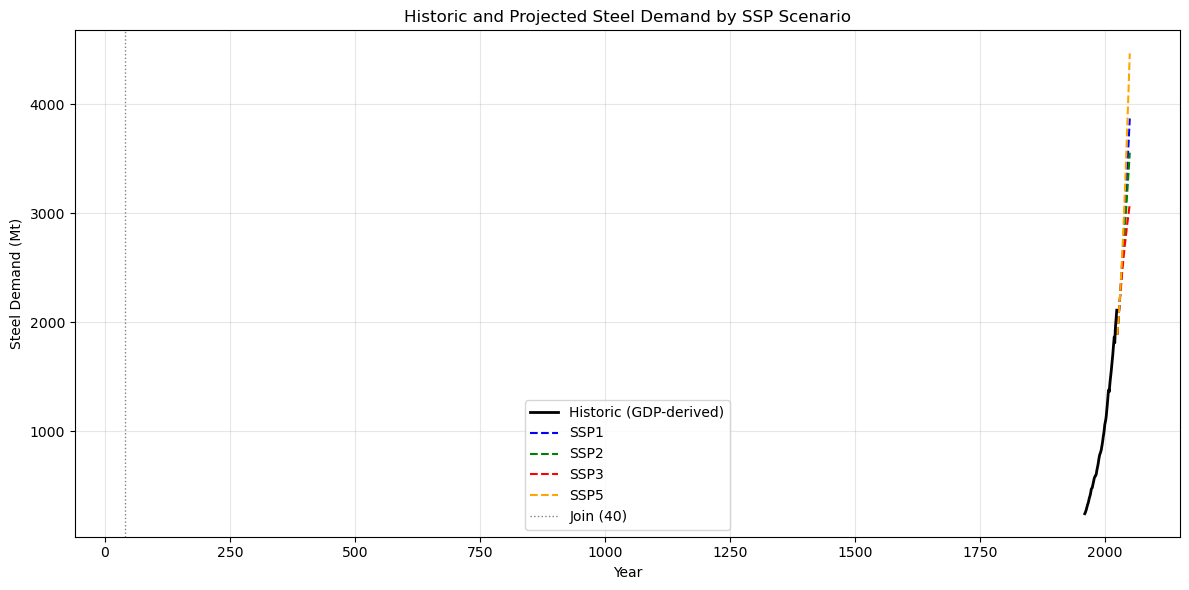

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot historic
ax.plot(steel_from_historic.index, steel_from_historic['Steel'], 
        color='black', linewidth=2, label='Historic (GDP-derived)', zorder=5)

# Plot future scenarios
colors = {'SSP1': 'blue', 'SSP2': 'green', 'SSP3': 'red', 'SSP5': 'orange'}
for scenario in ['SSP1', 'SSP2', 'SSP3', 'SSP5']:
    col = f'{scenario}_interpolated'
    if col in steel_future.columns:
        ax.plot(steel_future.index, steel_future[col],
                color=colors[scenario], linewidth=1.5, linestyle='--', label=scenario)

# Add vertical line at join point
ax.axvline(x=last_historic_year, color='grey', linestyle=':', linewidth=1, label=f'Join ({last_historic_year})')

ax.set_xlabel('Year')
ax.set_ylabel('Steel Demand (Mt)')
ax.set_title('Historic and Projected Steel Demand by SSP Scenario')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()